In [9]:
import sys
from pathlib import Path

# Path to the parent folder (where util.py is)
parent_path = Path().resolve().parent.parent  # notebook's parent directory
sys.path.append(str(parent_path))
import util
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = util.load_data(path_file='../../data_csv/Data_20251201_1223.csv')  

data_adults = data[(data["altersklasse"] == "Frauen") | (data["altersklasse"] == "Maenner")]

In [10]:

disciplines = data['disziplin'].unique()

years = np.sort(data['jahr'].unique())

counts = {}

for d in disciplines:
    counts[d] = []
    for y in years:
        count = len(data[(data['disziplin'] == d) & (data['jahr'] == y)])
        counts[d].append(count)

table = pd.DataFrame(counts, index=years).T  # transpose to have disciplines as rows
table.columns.name = 'jahr'

table

jahr,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
100 m,450,433,449,452,455,423,447,417,466,436,...,417,448,452,486,481,437,611,611,599,602
200 m,298,286,303,307,311,327,278,296,325,316,...,334,314,331,361,355,323,397,402,401,386
400 m,356,355,353,355,353,358,364,363,360,363,...,361,360,360,357,362,352,391,392,396,390
800 m,408,408,401,401,409,409,418,419,416,420,...,472,477,481,474,482,476,570,523,551,573
1500 m,353,352,354,352,352,356,359,358,356,359,...,342,348,361,351,362,361,401,394,388,375
3000 m,470,360,387,383,399,398,407,391,398,381,...,466,455,486,463,428,471,552,527,546,589
5000 m,337,211,245,236,235,243,251,245,254,247,...,245,243,259,246,260,254,300,289,293,298
10 000 m,127,118,129,131,117,123,128,121,146,132,...,157,147,174,165,168,132,184,152,162,176
10 km,158,359,356,361,357,360,364,358,361,356,...,351,348,369,358,365,291,401,396,343,358
Halbmarathon,153,157,155,155,140,154,157,153,158,160,...,143,143,167,151,159,124,146,190,199,199


In [7]:
data[(data['disziplin'] == '400 m') & (data['jahr'] == 2017)].count()

jahr            360
geschlecht      360
altersklasse    360
disziplin       360
leistung        360
wind              0
name            360
geburtsjahr     360
verein          360
datum           360
ort             360
dtype: int64

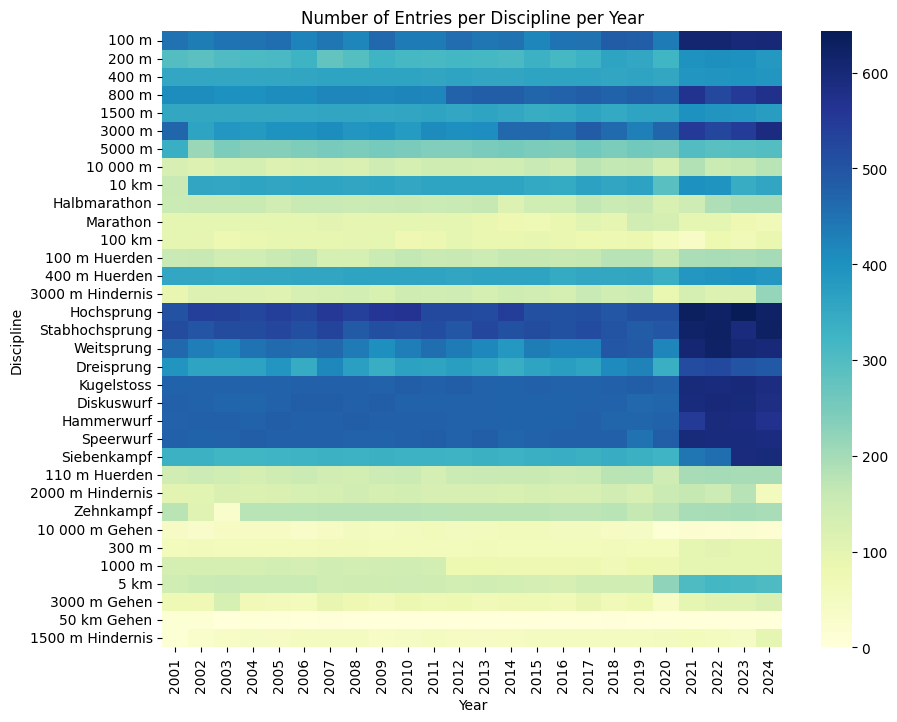

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# Draw heatmap
ax = ax = sns.heatmap(table, fmt="d", cmap="YlGnBu")
ax.set_yticks(np.arange(len(table.index)) + 0.5)  # Position der Labels korrigieren
ax.set_yticklabels(table.index, rotation=0)       # Namen anzeigen, horizontal

plt.title("Number of Entries per Discipline per Year")
plt.ylabel("Discipline")
plt.xlabel("Year")
plt.show()